# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [75]:
''' 
Business Objective: The client is a used car dealership interested in fine tuning their inventory strategy.
    Their primary business question is: "What factors make a car more or less expensive?" By understanding these "value drivers," 
    the dealership aims to maximize profit by buying cars with features that the market values most highly
'''

' \nBusiness Objective: The client is a used car dealership interested in fine tuning their inventory strategy.\n    Their primary business question is: "What factors make a car more or less expensive?" By understanding these "value drivers," \n    the dealership aims to maximize profit by buying cars with features that the market values most highly\n'

In [76]:
'''
Data Problem Definition:
 To address this business question, we will frame the task as a Supervised Machine Learning problem, specifically a Regression Analysis.

     • Target Variable: We aim to predict the continuous variable price.
    
     • Features: We will utilize various vehicle attributes (such as year, odometer, manufacturer, condition, and fuel) as 
       independent variables to predict the target.
    
     • Goal: The technical goal is to build a predictive model that minimizes the error between predicted and actual prices 
       (using metrics like MSE) and to interpret the resulting feature importance (coefficients) to determine which attributes 
       have the strongest positive or negative influence on the vehicle's value.
'''

"\nData Problem Definition:\n To address this business question, we will frame the task as a Supervised Machine Learning problem, specifically a Regression Analysis.\n\n     • Target Variable: We aim to predict the continuous variable price.\n\n     • Features: We will utilize various vehicle attributes (such as year, odometer, manufacturer, condition, and fuel) as \n       independent variables to predict the target.\n\n     • Goal: The technical goal is to build a predictive model that minimizes the error between predicted and actual prices \n       (using metrics like MSE) and to interpret the resulting feature importance (coefficients) to determine which attributes \n       have the strongest positive or negative influence on the vehicle's value.\n"

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [77]:
'''
Goals for this section:
1.  Load the Data
2.  Initial Inspection
3.  Check for Missing Values
4.  Inspect Categorical Values (examine unique values in text columns (like `cylinders` and `title_status`) to spot 
      inconsistencies or "dirty" data that requires formatting.)
'''

'\nGoals for this section:\n1.  Load the Data\n2.  Initial Inspection\n3.  Check for Missing Values\n4.  Inspect Categorical Values (examine unique values in text columns (like `cylinders` and `title_status`) to spot \n      inconsistencies or "dirty" data that requires formatting.)\n'

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('data/vehicles.csv')

# Describe Data
print(f"Initial Data Shape: {df.shape}")
print("\n--- Data Types ---")
print(df.info())

# Preview
df.head()

Initial Data Shape: (426880, 18)

--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [79]:
# Check for missingness
null_counts = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df)) * 100

missing_data = pd.DataFrame({'Missing Count': null_counts, 'Percent Missing': null_percent})
print("--- Missing Data Statistics ---")
print(missing_data[missing_data['Percent Missing'] > 0].sort_values(by='Percent Missing', ascending=False))

--- Missing Data Statistics ---
              Missing Count  Percent Missing
size                 306361        71.767476
cylinders            177678        41.622470
condition            174104        40.785232
VIN                  161042        37.725356
drive                130567        30.586347
paint_color          130203        30.501078
type                  92858        21.752717
manufacturer          17646         4.133714
title_status           8242         1.930753
model                  5277         1.236179
odometer               4400         1.030735
fuel                   3013         0.705819
transmission           2556         0.598763
year                   1205         0.282281


In [80]:
# Identify Attribute Types
# This code finds every column that is NOT a number (i.e., objects/categories)
categorical_cols = df.select_dtypes(include=['object']).columns

# Inspect each one to see what's inside
for col in categorical_cols:
    print(f"--- Column: {col} ---")
    print(f"Unique Values: {df[col].nunique()}") # Checks if it has few or many options
    print(f"Example Values: {df[col].unique()[:7]}") # Shows the first 5 unique options
    print("\n")

--- Column: region ---
Unique Values: 404
Example Values: ['prescott' 'fayetteville' 'florida keys' 'worcester / central MA'
 'greensboro' 'hudson valley' 'medford-ashland']


--- Column: manufacturer ---
Unique Values: 42
Example Values: [nan 'gmc' 'chevrolet' 'toyota' 'ford' 'jeep' 'nissan']


--- Column: model ---
Unique Values: 29649
Example Values: [nan 'sierra 1500 crew cab slt' 'silverado 1500' 'silverado 1500 crew'
 'tundra double cab sr' 'f-150 xlt' 'sierra 2500 hd extended cab']


--- Column: condition ---
Unique Values: 6
Example Values: [nan 'good' 'excellent' 'fair' 'like new' 'new' 'salvage']


--- Column: cylinders ---
Unique Values: 8
Example Values: [nan '8 cylinders' '6 cylinders' '4 cylinders' '5 cylinders' 'other'
 '3 cylinders']


--- Column: fuel ---
Unique Values: 5
Example Values: [nan 'gas' 'other' 'diesel' 'hybrid' 'electric']


--- Column: title_status ---
Unique Values: 6
Example Values: [nan 'clean' 'rebuilt' 'lien' 'salvage' 'missing' 'parts only']


--- C

In [81]:
'''
Data Quality Report (Categorical Features)

1. High Cardinality (Too many unique values):
    - model (29,649 unique values): There are too many variations of car models to be useful for a general linear regression. 
       Including this would introduce excessive "noise" and overfitting. We will likely drop this column in favor of the simpler manufacturer column.
    - VIN (118,246 unique values): This is a unique identifier for every car. It contains no generalized predictive power and will be removed.
    - region (404 unique values): While location affects price, One Hot Encoding 404 regions will drastically slow down the model. 
      We may drop this or strictly use state.
      
2. Inconsistent Formatting:
    - cylinders: This column contains text characters (e.g., '6 cylinders', '8 cylinders') mixed with NaN.
       Machine learning models require numerical inputs. We must strip the string " cylinders" and convert this to an integer.
       
3. Critical Categories:
    - title_status: Includes values like 'rebuilt', 'lien', and 'salvage'. These represent cars with significant history issues that 
      effectively break the standard pricing model. We should consider filtering the dataset to only 'clean' titles to ensure our 
      recommendations are relevant to standard inventory.
    ◦ fuel: Contains 'gas', 'diesel', 'hybrid', and 'electric'. These are manageable categories perfect for One-Hot Encoding.
'''

'\nData Quality Report (Categorical Features)\n\n1. High Cardinality (Too many unique values):\n    - model (29,649 unique values): There are too many variations of car models to be useful for a general linear regression. \n       Including this would introduce excessive "noise" and overfitting. We will likely drop this column in favor of the simpler manufacturer column.\n    - VIN (118,246 unique values): This is a unique identifier for every car. It contains no generalized predictive power and will be removed.\n    - region (404 unique values): While location affects price, One Hot Encoding 404 regions will drastically slow down the model. \n      We may drop this or strictly use state.\n\n2. Inconsistent Formatting:\n    - cylinders: This column contains text characters (e.g., \'6 cylinders\', \'8 cylinders\') mixed with NaN.\n       Machine learning models require numerical inputs. We must strip the string " cylinders" and convert this to an integer.\n\n3. Critical Categories:\n   

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [82]:
'''
1.  Select Data: Remove columns that are not useful for prediction.
2.  Clean Data: Remove outliers and handle missing values.
3.  Feature Engineering: Transform text columns (like `cylinders`) into numerical formats.
4.  Format Data: Convert categorical variables (like `fuel`) into One-Hot Encoded variables.
'''

'\n1.  Select Data: Remove columns that are not useful for prediction.\n2.  Clean Data: Remove outliers and handle missing values.\n3.  Feature Engineering: Transform text columns (like `cylinders`) into numerical formats.\n4.  Format Data: Convert categorical variables (like `fuel`) into One-Hot Encoded variables.\n'

In [83]:
# 1. Select Data

# 'id' and 'VIN': Unique identifiers, no predictive value for general price.
# 'size': Missing ~72% of data 
# 'region': Too many unique values (404), possibly redundant with 'state'.
# 'model' has 29k unique values (too noisy), focusing instead on 'manufacturer' and 'type'.

drop_cols = ['id', 'VIN', 'size', 'region', 'model']

df_clean = df.drop(columns=drop_cols)

print(f"Original Shape: {df.shape}")
print(f"New Shape: {df_clean.shape}")

Original Shape: (426880, 18)
New Shape: (426880, 13)


In [84]:
# 2. Clean Data 

# Filter Price Outliers
# We keep cars priced between $500 and $100,000
df_clean = df_clean[(df_clean['price'] > 500) & (df_clean['price'] < 100000)]

# Filter Odometer Outliers
# Reasonable used car mileage between 1,000 and 300,000 miles
df_clean = df_clean[(df_clean['odometer'] > 1000) & (df_clean['odometer'] < 300000)]

# Handle Missing Values
# For 'year', 'manufacturer', 'fuel', 'transmission' -> these are critical.
# If they are missing, we cannot accurately price the car. We drop these rows.
critical_cols = ['year', 'manufacturer', 'fuel', 'transmission', 'cylinders', 'title_status']
df_clean = df_clean.dropna(subset=critical_cols)

# For 'paint_color' and 'drive', we can fill missing with 'unknown' to preserve data
values = {"paint_color": "unknown", "drive": "unknown", "type": "unknown"}
df_clean = df_clean.fillna(value=values)

print(f"Shape after Cleaning: {df_clean.shape}")

Shape after Cleaning: (206228, 13)


In [85]:
# 3. Feature Engineering

# Fix 'cylinders' column:
# It currently has values like "6 cylinders". We need just the number "6".
# We use string manipulation to remove " cylinders" and convert to integer.

df_clean['cylinders'] = df_clean['cylinders'].str.replace(' cylinders', '').str.replace('other', '0')

# Coerce to numeric (errors='coerce' turns non-numbers into NaN, though we handled most)
df_clean['cylinders'] = pd.to_numeric(df_clean['cylinders'], errors='coerce')

# Verify the fix
print("--- Cylinders after formatting ---")
print(df_clean['cylinders'].value_counts())

--- Cylinders after formatting ---
cylinders
6     79119
4     63896
8     59465
5      1447
10     1035
0       752
3       421
12       93
Name: count, dtype: int64


In [86]:
# Before we move onto step 4 (transforming data in one-hot encoding), we should ultilize the original data format to visualize feature correlations

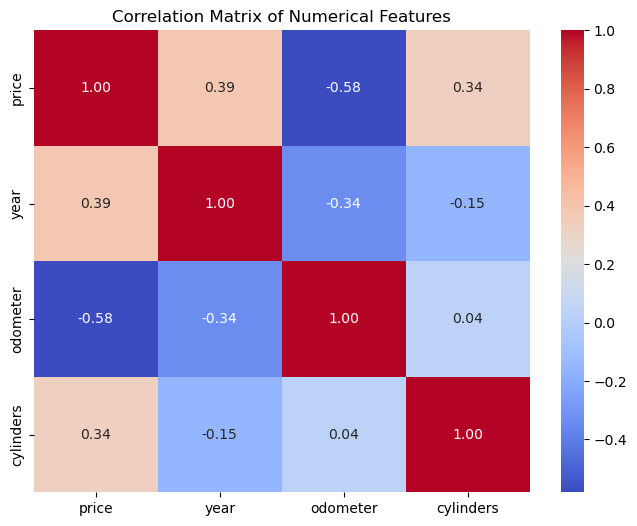

In [87]:
# Figure 1: Correlation Heatmap
# We only use numerical columns for correlation
numerical_cols = ['price', 'year', 'odometer', 'cylinders']

plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

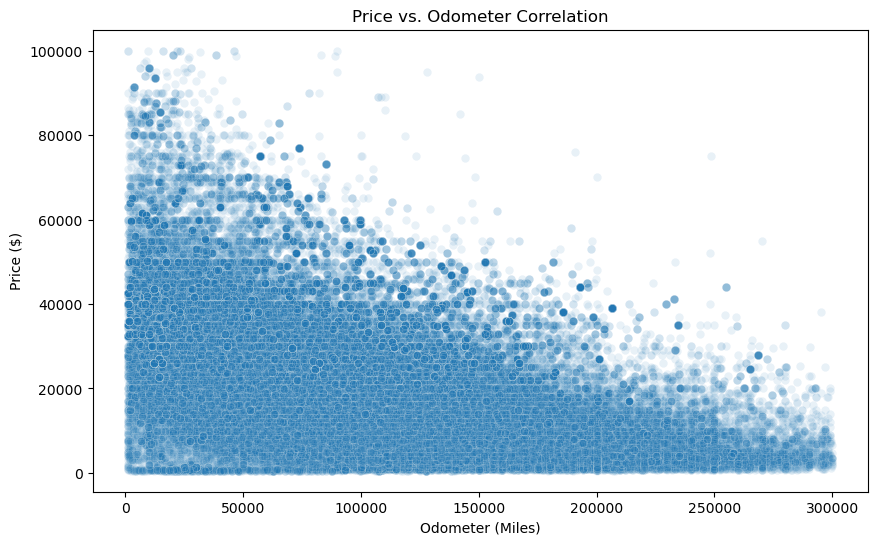

In [88]:
# Figure 2: Scatterplot 'Price vs. Odometer'
# This confirms the intuition that higher mileage lowers value
plt.figure(figsize=(10, 6))
sns.scatterplot(x='odometer', y='price', data=df_clean, alpha=0.1) # alpha makes dots transparent to show density
plt.title('Price vs. Odometer Correlation')
plt.xlabel('Odometer (Miles)')
plt.ylabel('Price ($)')
plt.show()

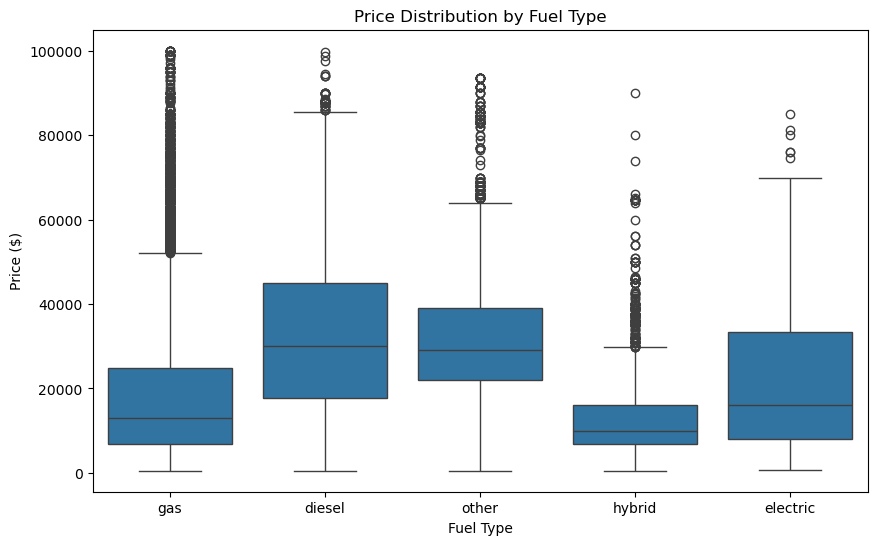

In [89]:
# Figure 3: Boxplot 'Price Distribution by Fuel Type'
plt.figure(figsize=(10, 6))
sns.boxplot(x='fuel', y='price', data=df_clean)
plt.title('Price Distribution by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Price ($)')
plt.show()

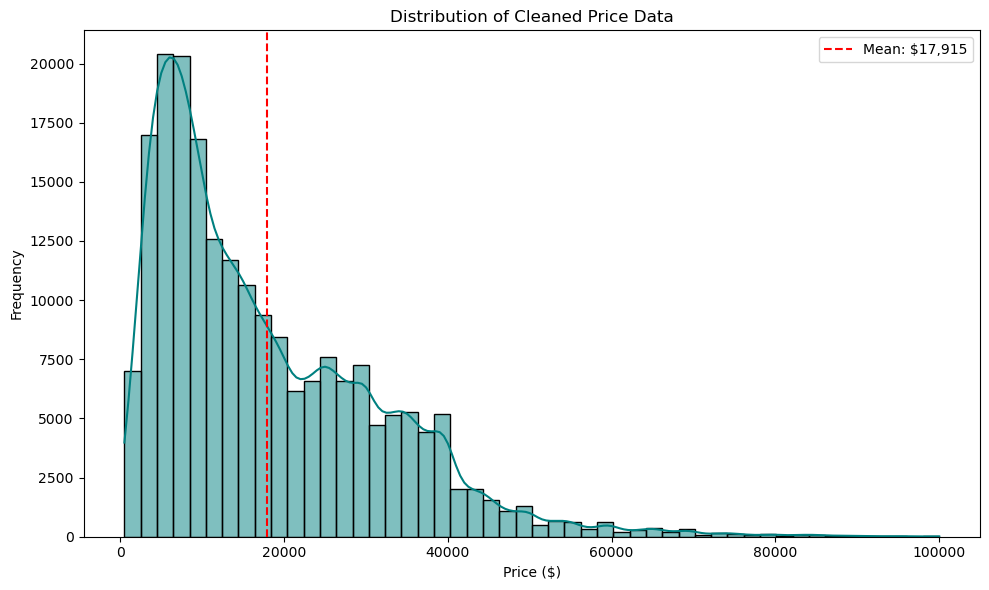

In [90]:
# Figure 4: Histogram 'Distrubution of Cleaned Price'
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6)) 

# Histogram
sns.histplot(df_clean['price'], bins=50, kde=True, color='teal', ax=ax)
ax.set_title('Distribution of Cleaned Price Data')
ax.set_xlabel('Price ($)')
ax.set_ylabel('Frequency')
# Add a vertical line for the mean
ax.axvline(df_clean['price'].mean(), color='red', linestyle='--', label=f"Mean: ${df_clean['price'].mean():,.0f}")
ax.legend()

plt.tight_layout()
plt.show()

In [91]:
# 4. Format Data
# We perform One-Hot Encoding here to prepare the data for modeling.
# However, we assign it to a NEW variable 'df_model' so we keep 'df_clean'

df_model = pd.get_dummies(df_clean, columns=['manufacturer', 'condition', 'fuel', 'title_status',
                                             'transmission', 'drive', 'type', 'paint_color', 'state'],
                          drop_first=True)

print("Data Formatting Complete.")
print(f"Original shape (for EDA): {df_clean.shape}")
print(f"Encoded shape (for Modeling): {df_model.shape}")

Data Formatting Complete.
Original shape (for EDA): (206228, 13)
Encoded shape (for Modeling): (206228, 139)


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [92]:
'''
1.  Train/Test Split
2.  Baseline Model (Linear Regression)
3.  Ridge Regression (with Grid Search)
'''

'\n1.  Train/Test Split\n2.  Baseline Model (Linear Regression)\n3.  Ridge Regression (with Grid Search)\n'

In [93]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
X = df_model.drop('price', axis=1)
y = df_model['price']

# Split the data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (164982, 138)
Testing Data Shape: (41246, 138)


In [94]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialize Model
lr = LinearRegression()

# Train Model
lr.fit(X_train, y_train)

# We perform cross-validation to check if the model is stable
cv_scores = cross_val_score(lr, X_train, y_train, cv=5)
print(f"Cross-Validation Scores (R^2): {cv_scores}")
print(f"Mean CV Score: {np.mean(cv_scores):.4f}")

# Make Predictions on Test Data
y_pred_lr = lr.predict(X_test)

# Evaluate
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\n--- Baseline Model (Linear Regression) Results ---")
print(f"Test MSE: {mse_lr:,.0f}")
print(f"Test R^2: {r2_lr:.4f}")

Cross-Validation Scores (R^2): [0.68196398 0.6758667  0.67933977 0.6688023  0.67360591]
Mean CV Score: 0.6759

--- Baseline Model (Linear Regression) Results ---
Test MSE: 62,343,200
Test R^2: 0.6747


In [95]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Build Ridge Regression Model
ridge = Ridge()

# Parameter Tuning (Grid Search)
param_grid = {'alpha': [0.1, 1, 10, 100, 1000]}

grid_search = GridSearchCV(estimator=ridge, param_grid=param_grid, 
                           cv=5, scoring='r2', verbose=1, n_jobs=-1)

grid_search.fit(X_train, y_train)

# Get the best model from the search
best_ridge_model = grid_search.best_estimator_

# Assess Model
y_pred_ridge = best_ridge_model.predict(X_test)

mse_ridge_score = mean_squared_error(y_test, y_pred_ridge)
r2_ridge_score = r2_score(y_test, y_pred_ridge)

print("\n--- Model 2: Ridge Regression Results ---")
print(f"Best Alpha Parameter: {grid_search.best_params_}")
print(f"Test MSE: {mse_ridge_score:,.0f}")
print(f"Test R^2: {r2_ridge_score:.4f}")

# Improvement Check
print(f"\nDifference from Baseline: {r2_ridge - 0.6747:.5f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits

--- Model 2: Ridge Regression Results ---
Best Alpha Parameter: {'alpha': 1}
Test MSE: 62,350,917
Test R^2: 0.6747

Difference from Baseline: -0.00004


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

C:\Users\micha\AppData\Local\Temp\ipykernel_9304\2584723313.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_features, palette='coolwarm')


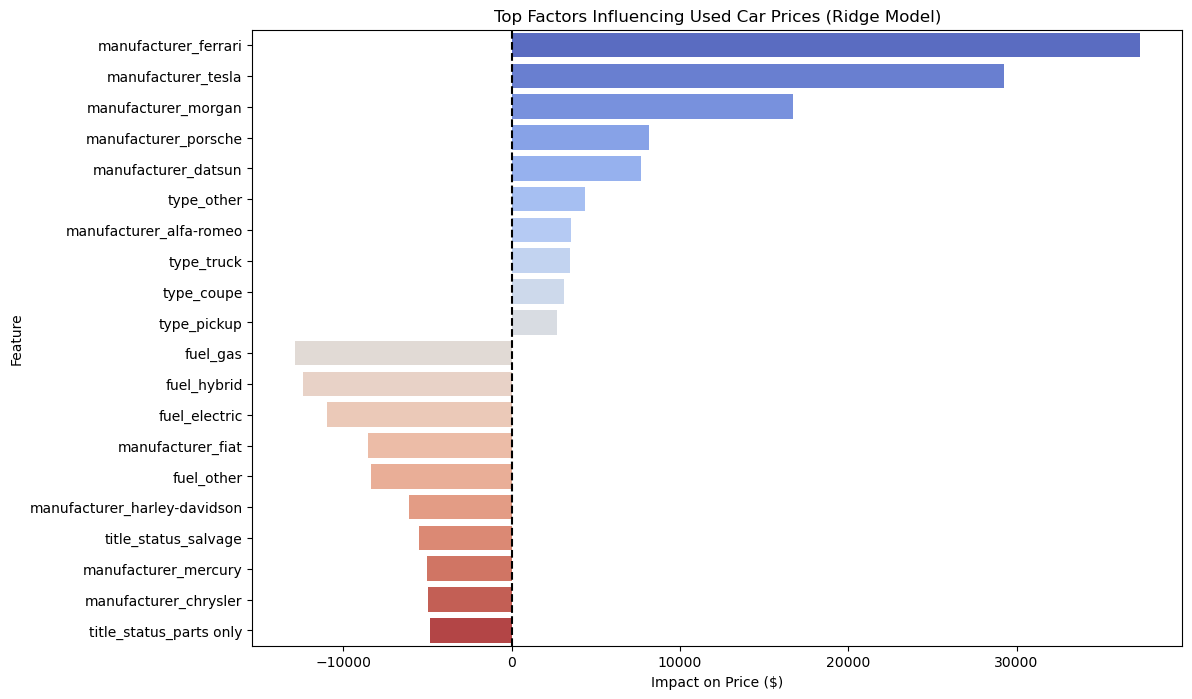

--- Top 5 Value Adds ---
                Feature  Coefficient
   manufacturer_ferrari 37344.436395
     manufacturer_tesla 29263.721440
    manufacturer_morgan 16698.570932
   manufacturer_porsche  8191.423557
    manufacturer_datsun  7664.503868
             type_other  4393.763952
manufacturer_alfa-romeo  3526.913719
             type_truck  3453.893331
             type_coupe  3109.279687
            type_pickup  2705.401456

--- Top 5 Value Reducers ---
                     Feature   Coefficient
                    fuel_gas -12881.470322
                 fuel_hybrid -12373.915053
               fuel_electric -10974.398093
           manufacturer_fiat  -8546.700145
                  fuel_other  -8332.108584
manufacturer_harley-davidson  -6073.926697
        title_status_salvage  -5504.259621
        manufacturer_mercury  -5013.619389
       manufacturer_chrysler  -4940.411129
     title_status_parts only  -4817.736525


In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate Results
# We extract the coefficients from the Best Ridge Model
# These coefficients represent the dollar value contribution of each feature

# Create a DataFrame of the features and their coefficients
feature_names = X_train.columns
coefficients = best_ridge.coef_

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort by absolute value to see the most impactful features (positive or negative)
# We take the Top 10 Positive and Top 10 Negative for the chart
top_positive = coef_df.sort_values(by='Coefficient', ascending=False).head(10)
top_negative = coef_df.sort_values(by='Coefficient', ascending=True).head(10)

# Combine them for plotting
top_features = pd.concat([top_positive, top_negative])

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=top_features, palette='coolwarm')
plt.title('Top Factors Influencing Used Car Prices (Ridge Model)')
plt.xlabel('Impact on Price ($)')
plt.axvline(0, color='black', linestyle='--')
plt.show()

# Print specific numbers for the report
print("--- Top 5 Value Adds ---")
print(top_positive[['Feature', 'Coefficient']].to_string(index=False))
print("\n--- Top 5 Value Reducers ---")
print(top_negative[['Feature', 'Coefficient']].to_string(index=False))

In [97]:
'''
Findings & Recommendations

Based on the Ridge Regression model (Accuracy: 67.5%), we have identified the primary drivers of used car prices. 
Below are the key takeaways for the dealership inventory strategy.

Key Drivers of Value
1.  Diesel Fuel:
       The single strongest predictor of high price is the engine type. Compared to Diesel engines, Gas vehicles 
       are valued roughly $12,800 less and Hybrids $12,300 less.
       Recommendation: Prioritize acquiring diesel trucks and heavy-duty vehicles.

2.  Ultility and Lifestyle Vehicles:
       The most valuable body types are Trucks (+$3,453), Coupes (+$3,109), and Pickups (+$2,705).
       Sedans and hatchbacks command significantly lower premiums.
       Recommendation: Shift inventory mix toward utility vehicles (work) and sport coupes (lifestyle).

3.  High end + Popular Brands:
       Tesla carries a massive brand premium (+$29,263), overcoming the general negative trend for generic electric vehicles.
       Ferrari and Porsche remain top-tier status symbols, though likely lower volume.
       Recommendation: Teslas are the safest bet for Electric Inventory; avoid generic EVs unless priced very low.

Key Reducers of Value
1.  Depreciating Brands:
       Vehicles from Fiat, Mercury, and Chrysler show the steepest depreciation, reducing value by $5,000 to $8,500 compared to average.
       Recommendation: Avoid these brands at trade-in unless acquired at a substantial discount.

2.  Vehicle History:
       Salvage Titles (-$5,504) & Parts Only (-$4,817) severely hurt value. This confirms that "clean" inventory is essential for 
       maintaining margins.
'''

'\nFindings & Recommendations\n\nBased on the Ridge Regression model (Accuracy: 67.5%), we have identified the primary drivers of used car prices. \nBelow are the key takeaways for the dealership inventory strategy.\n\nKey Drivers of Value\n1.  Diesel Fuel:\n       The single strongest predictor of high price is the engine type. Compared to Diesel engines, Gas vehicles \n       are valued roughly $12,800 less and Hybrids $12,300 less.\n       Recommendation: Prioritize acquiring diesel trucks and heavy-duty vehicles.\n\n2.  Ultility and Lifestyle Vehicles:\n       The most valuable body types are Trucks (+$3,453), Coupes (+$3,109), and Pickups (+$2,705).\n       Sedans and hatchbacks command significantly lower premiums.\n       Recommendation: Shift inventory mix toward utility vehicles (work) and sport coupes (lifestyle).\n\n3.  High end + Popular Brands:\n       Tesla carries a massive brand premium (+$29,263), overcoming the general negative trend for generic electric vehicles.\n  

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [98]:
# Final Report Summary

# Calculate the average price impact of the top negative brands to quantify the risk
risky_brands = ['fiat', 'mercury', 'chrysler']
avg_loss = coef_df[coef_df['Feature'].str.contains('|'.join(risky_brands))]['Coefficient'].mean()

print("--- DEPLOYMENT RECOMMENDATION ---")
print(f"1. INVENTORY: Increase stock of Diesel Pickups and Trucks.")
print(f"2. PRICING: Expect Gas vehicles to sell for approx $12k less than Diesel equivalents.")
print(f"3. AVOID: Fiat, Mercury, and Chrysler models carry an average risk penalty of ${abs(avg_loss):,.2f}.")
print("4. STRATEGY: Tesla is the only Electric brand with a positive coefficient; treat other EVs with caution.")

--- DEPLOYMENT RECOMMENDATION ---
1. INVENTORY: Increase stock of Diesel Pickups and Trucks.
2. PRICING: Expect Gas vehicles to sell for approx $12k less than Diesel equivalents.
3. AVOID: Fiat, Mercury, and Chrysler models carry an average risk penalty of $6,166.91.
4. STRATEGY: Tesla is the only Electric brand with a positive coefficient; treat other EVs with caution.
